# Forest Plot: Effect of Zip Code Income Quartile on Inspection SCORE

Pure visualization notebook: loads the coefficient table and model-ready data saved by `02_analysis.ipynb` (which fits one shared OLS model of SCORE on cuisine group, restaurant-name keywords, and zip-code income quartile) and draws the income-quartile slice of that model. See `03a_cuisine_forest_plot.ipynb` and `03b_keyword_forest_plot.ipynb` for the other two predictor groups.

**Income data:** `utils.INCOME_DATA_SOURCE` currently = `"fallback"`. Real zip-code (ZCTA) median household income comes from the Census Bureau's American Community Survey 5-year estimates, pulled live from the public Census API and cached to `data/median_income_by_zip.csv` (`utils.get_income_by_zip`) -- but that requires a Census API key that isn't available yet, so `02_analysis.ipynb` instead used `utils.NYC_ZIP_INCOME_TIER_FALLBACK`: an **approximate** income tier per zip code built from general knowledge of NYC neighborhood income patterns, *not* official Census/ACS data. Treat this notebook's income results as illustrative only -- once a Census API key is available, flip `INCOME_DATA_SOURCE` to `"real"` in `utils.py` and rerun `02_analysis.ipynb` (then this notebook); no other code changes are needed.

**Takes in:** `output/shared_model_coefficients.csv`, `data/model_ready_inspections.csv` (both written by `02_analysis.ipynb`)

**Outputs:** `output/forest_plot_income.png`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import utils

## Load saved model results

In [2]:
coef_table = utils.load_model_coefficients()
model_ready = pd.read_csv(utils.MODEL_READY_PATH)
print(f"Loaded {len(coef_table)} model coefficients and {len(model_ready):,} model-ready rows")

Loaded 27 model coefficients and 131,466 model-ready rows


## Forest plot: zip code income quartile

Coefficients (95% CI) for the 3 non-reference income quartiles vs. the reference group (Q1, lowest income), sorted by absolute effect size. Blue = higher SCORE (worse), red = lower SCORE (better).

Saved forest plot to /Users/ethan/qss20-nyc-restaurant-inspections/output/forest_plot_income.png


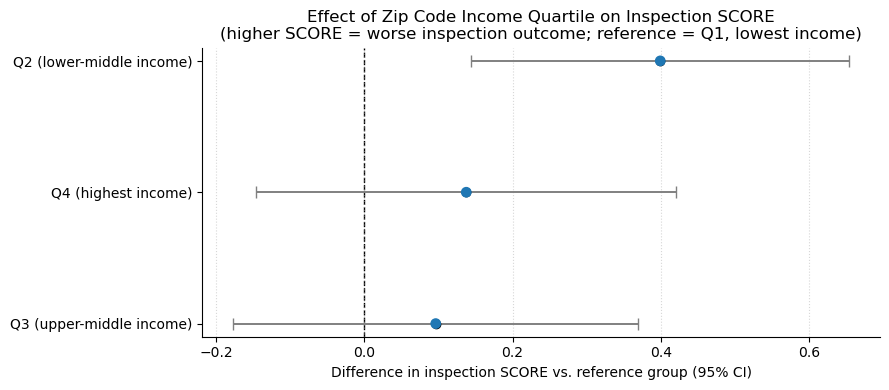

,label,coef,ci_low,ci_high,abs_coef
0,Q3 (upper-middle income),0.096248,-0.177508,0.370004,0.096248
1,Q4 (highest income),0.137492,-0.145792,0.420776,0.137492
2,Q2 (lower-middle income),0.399373,0.144329,0.654417,0.399373


In [3]:
utils.forest_plot(
    coef_table,
    prefix="income_group_",
    label_fn=lambda n: n.replace("income_group_", ""),
    title="Effect of Zip Code Income Quartile on Inspection SCORE\n"
          "(higher SCORE = worse inspection outcome; reference = Q1, lowest income)",
    save_path=f"{utils.OUTPUT_DIR}/forest_plot_income.png",
)